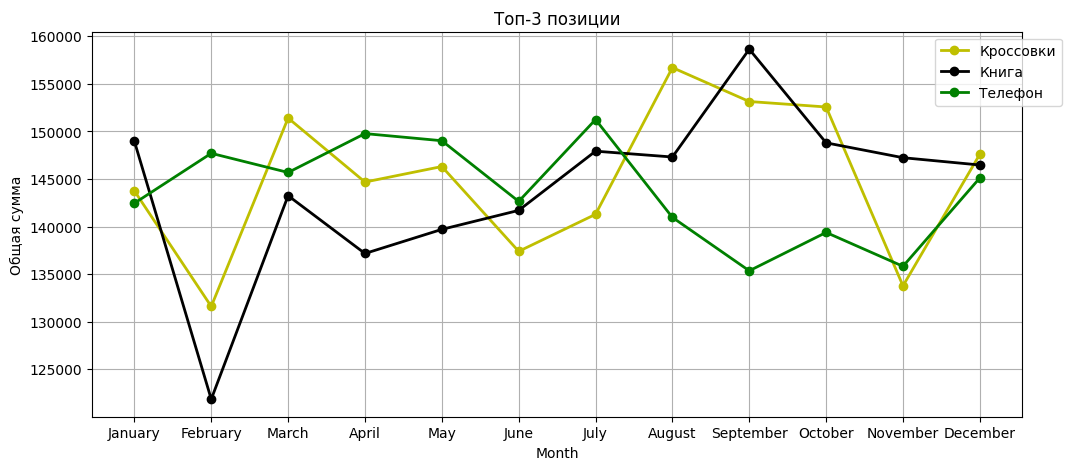

,Товар,Общая сумма
0,Кроссовки,1740201.02
1,Книга,1728988.54
2,Телефон,1725125.19


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

read_file = pd.read_csv('генерированный_файл.csv')
main = pd.DataFrame(read_file)
main['Общая сумма'] = main['Количество'] * main['Цена за единицу']
main['Дата'] = pd.to_datetime(main['Дата'])
main['Номер месяца'] = main['Дата'].dt.month
main['Дата'] = main['Дата'].dt.month_name()

main_to_group = main[['Номер месяца','Дата','Товар', 'Общая сумма']]
groupby_main_top3 = main_to_group.groupby(['Товар']).agg('sum',['Общая сумма']).reset_index()
groupby_main_plot = main_to_group.groupby(['Номер месяца','Дата','Товар']).agg('sum',['Общая сумма']).reset_index() ##

top_to_3 = groupby_main_top3.sort_values(by=['Общая сумма'], ascending=False).head(3).reset_index(drop=True)

product_list = []

for prod in top_to_3['Товар']:
    product_list.append(prod)

top_1 = groupby_main_plot[groupby_main_plot['Товар']==product_list[0]].reset_index(drop=True)
top_2 = groupby_main_plot[groupby_main_plot['Товар']==product_list[1]].reset_index(drop=True)
top_3 = groupby_main_plot[groupby_main_plot['Товар']==product_list[2]].reset_index(drop=True)


plt.figure(figsize=(12, 5))

month = groupby_main_plot['Дата'].unique()

plt.plot(month, top_1['Общая сумма'], marker='o', color='y', linestyle='-', linewidth=2, label=product_list[0])
plt.plot(month, top_2['Общая сумма'], marker='o', color='k', linestyle='-', linewidth=2, label=product_list[1])
plt.plot(month, top_3['Общая сумма'], marker='o', color='g', linestyle='-', linewidth=2, label=product_list[2])


plt.title('Топ-3 позиции')
plt.xlabel('Month')
plt.ylabel('Общая сумма')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()
top_to_3[['Товар', 'Общая сумма']]
